In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 100

df = pd.DataFrame({
    "Age": np.random.randint(18, 60, n),
    "Income": np.random.randint(20000, 100000, n),
    "Purchase_Amount": np.random.randint(500, 5000, n),
    "Savings": np.random.randint(5000, 50000, n),
    "Credit_Score": np.random.randint(300, 850, n)
})

df["Purchased"] = (
    (df["Purchase_Amount"] > 2000) |
    (df["Age"] < 25)
).astype(int)

df.head()

,Age,Income,Purchase_Amount,Savings,Credit_Score,Purchased
0,56,28392,646,16093,393,0
1,46,50535,3719,23070,752,1
2,32,98603,3411,40777,503,1
3,25,72256,2234,21538,517,1
4,38,55222,2343,15729,773,1


In [2]:
X = df.drop("Purchased", axis=1)
y = df["Purchased"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100, 5)
y shape: (100,)


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

baseline_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Baseline CV Scores:", baseline_scores)
print("Baseline Mean Accuracy:", round(baseline_scores.mean(), 4))

Baseline CV Scores: [0.95 1.   1.   1.   0.95]
Baseline Mean Accuracy: 0.98


In [4]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X, y)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", round(grid_search.best_score_, 4))

Best Parameters: {'max_depth': 3, 'n_estimators': 50}
Best CV Accuracy: 0.98


In [5]:
tuned_model = grid_search.best_estimator_

tuned_scores = cross_val_score(
    tuned_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

performance_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Tuned Random Forest"
    ],
    "Mean CV Accuracy": [
        baseline_scores.mean(),
        tuned_scores.mean()
    ],
    "Standard Deviation": [
        baseline_scores.std(),
        tuned_scores.std()
    ]
})

print(performance_comparison)

                    Model  Mean CV Accuracy  Standard Deviation
0  Baseline Random Forest              0.98            0.024495
1     Tuned Random Forest              0.98            0.024495


In [6]:
performance_comparison.to_csv(
    "day26_performance_comparison.csv",
    index=False
)

print("Performance comparison report saved successfully!")

Performance comparison report saved successfully!


In [7]:
best_parameters = pd.DataFrame([{
    "n_estimators": grid_search.best_params_["n_estimators"],
    "max_depth": grid_search.best_params_["max_depth"],
    "Best CV Accuracy": grid_search.best_score_
}])

best_parameters.to_csv(
    "day26_best_parameters.csv",
    index=False
)

print(best_parameters)
print("\nBest parameter report saved successfully!")

   n_estimators  max_depth  Best CV Accuracy
0            50          3              0.98

Best parameter report saved successfully!


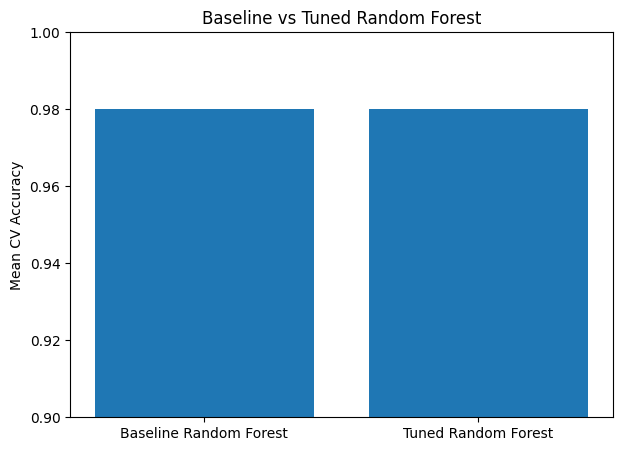

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    performance_comparison["Model"],
    performance_comparison["Mean CV Accuracy"]
)

plt.ylim(0.9, 1.0)
plt.ylabel("Mean CV Accuracy")
plt.title("Baseline vs Tuned Random Forest")

plt.show()